### **Traffic Analysis**

#### **what is traffic?**
#### Traffic refers to the movement of vehicles or pedestrians on roads and junctions.
#### **Why Does It Happen?**
#### Traffic occurs when demand (the number of drivers) exceeds supply (road capacity).
#### **How Does It Form?**
#### Traffic builds dynamically through chain reactions:
#### 1.Bottlenecks
#### 2.The Accordion Effect


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('traffic.csv')
df.sample(5)

,DateTime,Junction,Vehicles,ID
17471,2016-02-28 23:00:00,2,9,20160228232
852,2015-12-06 12:00:00,1,19,20151206121
17087,2016-02-12 23:00:00,2,11,20160212232
37941,2016-10-30 21:00:00,3,10,20161030213
21015,2016-07-25 15:00:00,2,18,20160725152


In [3]:
df.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

### **Dataset Overview**

#### The dataset contains traffic records from three years: 2015, 2016, and 2017. This dataset contains traffic information collected from different road junctions over a period of time. The main purpose of the dataset is to study vehicle movement patterns and understand how traffic changes across different timings and locations.

### **Literature Review**

#### Exploratory Data Analysis (EDA) is an important step in traffic data analysis because it helps in understanding traffic patterns and the overall behavior of vehicle movement.
#### Previous studies show that traffic patterns are closely connected to human daily activities.
#### **1. Fundamental Traffic Relation (Volume vs. Capacity):** The relationship between traffic volume and road capacity explains how the number of vehicles affects traffic flow. Traffic volume refers to the number of vehicles moving on a road, while road capacity is the maximum number of vehicles a road can handle efficiently. When traffic volume remains below road capacity, vehicles move smoothly. However, when the number of vehicles exceeds the road’s capacity, congestion and traffic jams begin to occur.
#### **2. Spatio-Temporal Rush Hour Cycles (Peak hour traffic):** Traffic changes based on time and location. It is usually high during morning and evening rush hours when people travel for work or school. Busy junctions show more traffic compared to less active areas. This pattern repeats daily and is known as the commuter rush hour cycle(peak hour taffic).
#### **3. Shockwave Dynamics & Phantom Bottlenecks (The Accordion Effect)** Sometimes in traffic, one car slows down suddenly and other cars also start braking one after another. This creates a wave of slow and fast movement in traffic.Even without any accident or signal, traffic can still become slow or jammed. This is called a phantom traffic jam or accordion effect.
#### **Academic References:**
#### **Greenshields, B. D. (1935)** A Study of Traffic Capacity. Highway Research Board Proceedings.
#### **Chawla, S., et al. (2012)** Visual Analytics of Urban Traffic Data. IEEE Transactions on Intelligent Transportation Systems.

### **Hypotheses to Test**

#### **H1 (Time-based Traffic Pattern):**
#### Vehicle counts show clear patterns during weekdays, with higher traffic in the morning and evening peak hours due to people traveling for work and daily activities.
#### **H2 (Weekday vs Weekend Difference):**
#### Traffic patterns change on weekends. The usual morning and evening peaks become less sharp, and traffic is more evenly spread during the day.
#### **H3 (Junction-wise Traffic Difference):**
#### Different junctions experience different traffic levels. Some junctions consistently handle more vehicles than others, acting as major traffic points or bottlenecks.

### **Feature Understanding**

#### **DateTime:** The exact date and hour the traffic was recorded.
#### **Junction:** A specific road crossing or point on the road where traffic data is collected.
#### **Vehicles:** The count of vehicles (volume) passed during that hour.
#### **ID:** A unique identifier for every single observation.

### **Data Understanding**

#### This section focuses on understanding the structure, quality, and basic characteristics of the dataset before starting cleaning or visualization

In [4]:
df.shape

(48120, 4)

#### The datset contains 48120 rows and 4 columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


#### There are no missing values in any column, which means the data is complete and clean.Most columns are numerical, except DateTime, which is stored as text and can be converted into proper datetime format in preprocessing for better analysis. 

In [6]:
df.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

#### There are no null values in any column.

In [7]:
df.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


#### The statistical summary shows how the data is spread. “Vehicles” shows traffic count, which changes over time. “Junction” shows different locations. “ID” is just a unique number and not useful for analysis.

In [8]:
df.duplicated().sum()

np.int64(0)

#### There is no duplicate values in any columns.

### **Final Summary for Data Cleaning**

#### The dataset contains traffic information collected from different junctions over time. It has 48,120 records and four columns: DateTime, Junction, Vehicles, and ID. There are no missing values, so the data is complete and ready for analysis.
#### Each record shows the number of vehicles at a specific junction and time. “Vehicles” represents traffic volume, “Junction” shows different locations, “DateTime” shows when the data was recorded, and “ID” is only a unique identifier. Overall, the dataset is clean and helps in understanding traffic patterns across time and locations.

### **Date Transformation**

In [9]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Date'] = df['DateTime'].dt.date
df['Time'] = df['DateTime'].dt.time
df['Weekday'] = df['DateTime'].dt.day_name()
df['Year'] = df['DateTime'].dt.year
df['Hour']=df['DateTime'].dt.hour
df['Month'] = df['DateTime'].dt.month
df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday']).astype(int)
df['Day'] = df['DateTime'].dt.day



In [10]:
df.sample (5)

,DateTime,Junction,Vehicles,ID,Date,Time,Weekday,Year,Hour,Month,Is_Weekend,Day
37122,2016-09-26 18:00:00,3,28,20160926183,2016-09-26,18:00:00,Monday,2016,18,9,0,26
44585,2017-02-03 17:00:00,4,8,20170203174,2017-02-03,17:00:00,Friday,2017,17,2,0,3
37590,2016-10-16 06:00:00,3,7,20161016063,2016-10-16,06:00:00,Sunday,2016,6,10,1,16
45388,2017-03-09 04:00:00,4,4,20170309044,2017-03-09,04:00:00,Thursday,2017,4,3,0,9
15421,2015-12-05 13:00:00,2,8,20151205132,2015-12-05,13:00:00,Saturday,2015,13,12,1,5


#### We extracted year, date, time, and weekday from the DateTime column to analyze traffic patterns across different time levels such as daily, weekly, and yearly trends.

### **Univariate Analysis**

#### Univariate analysis helps us understand the basic distribution and behavior of each feature separately.

In [11]:
df.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'Date', 'Time', 'Weekday',
       'Year', 'Hour', 'Month', 'Is_Weekend', 'Day'],
      dtype='object')

### **Junction**

<Axes: xlabel='Junction', ylabel='count'>

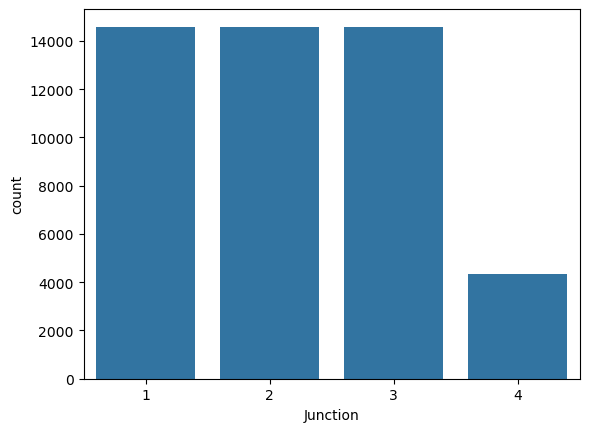

In [12]:
sns.countplot(x='Junction',data=df)

In [13]:
df['Junction'].value_counts()

Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

#### The data is evenly collected from Junction 1, 2, and 3, each having **14,592 records**, which shows equal importance given to these locations. However, Junction 4 has only **4,344 records**, which is comparatively lower. This means traffic data is not equally distributed across all junctions, and Junction 4 has fewer observations compared to the others.

### **Vehicles**

<Axes: xlabel='Vehicles', ylabel='Count'>

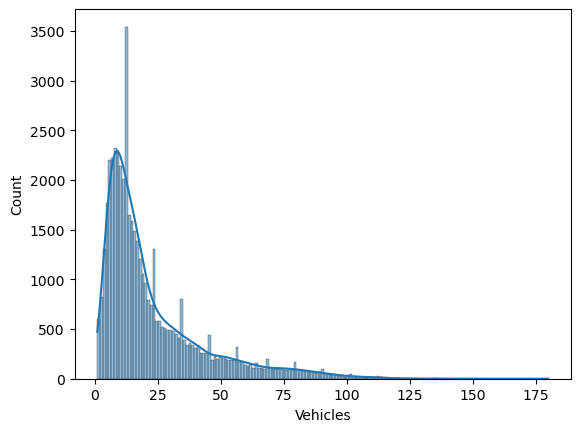

In [14]:
sns.histplot(x='Vehicles',data=df,kde=True)

In [15]:
df['Vehicles'].describe()

count    48120.000000
mean        22.791334
std         20.750063
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64

#### The traffic data shows that vehicle counts vary widely across different time periods. On average, around **23 vehicles** are recorded, but the actual values change a lot depending on the situation. Most of the time, traffic stays between **9 and 29 vehicles**, showing normal or moderate flow. However, in some cases, traffic can go very high, reaching up to **180 vehicles**, which indicates peak congestion periods. Overall, the data shows fluctuating traffic conditions with occasional heavy spikes.


### **Hour**

<Axes: xlabel='Hour', ylabel='Count'>

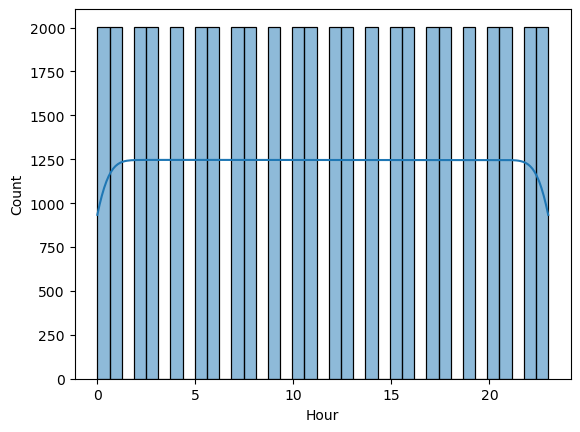

In [16]:
sns.histplot(x='Hour',data=df,kde=True)

In [17]:
df['Hour'].describe()

count    48120.000000
mean        11.500000
std          6.922258
min          0.000000
25%          5.750000
50%         11.500000
75%         17.250000
max         23.000000
Name: Hour, dtype: float64

#### The data shows traffic records across all hours of the day. The average hour value is around **11.5**, meaning data is fairly distributed across the full day. Most of the records fall between **5 to 17 hours**, which represents morning to evening time. The minimum value is **0 (midnight)** and the maximum is **23 (late night)**, showing that traffic is recorded for the entire 24-hour cycle. Overall, the data covers full-day traffic patterns with a balanced distribution across hours.


### **Weekday**

<Axes: xlabel='Weekday', ylabel='count'>

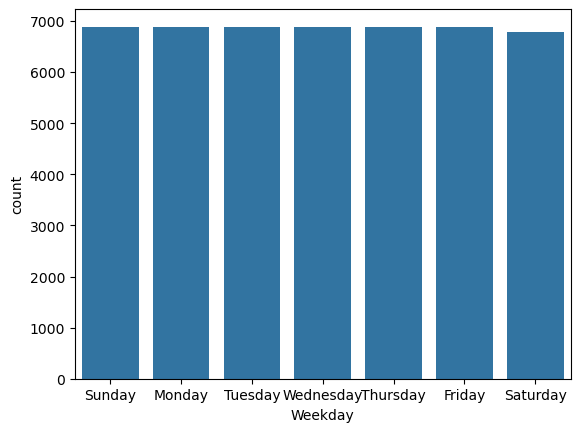

In [18]:
sns.countplot(x='Weekday',data=df)

In [19]:
df['Weekday'].value_counts()

Weekday
Sunday       6888
Monday       6888
Tuesday      6888
Wednesday    6888
Thursday     6888
Friday       6888
Saturday     6792
Name: count, dtype: int64

#### The dataset shows almost equal traffic records across all weekdays, including Sunday to Friday, with **6888 records each**. Saturday has slightly fewer records (**6792**). Overall, the data is well balanced across the week, which helps in comparing traffic patterns between different days.


### **Is_Weekend**

<Axes: xlabel='Is_Weekend', ylabel='count'>

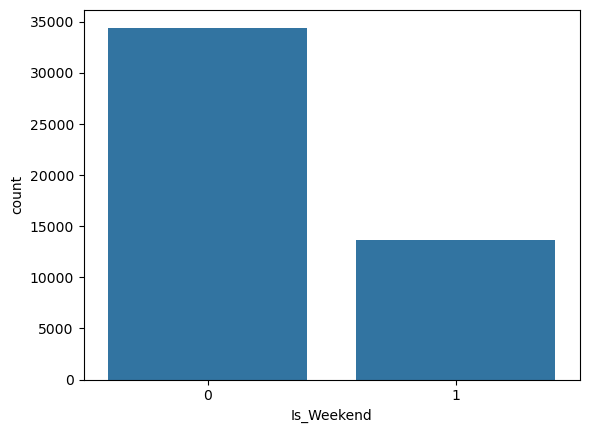

In [20]:
sns.countplot(x='Is_Weekend',data=df)

In [21]:
df['Is_Weekend'].value_counts()

Is_Weekend
0    34440
1    13680
Name: count, dtype: int64

#### “In the Is_Weekend column, 0 represents weekdays (Monday–Friday) and 1 represents weekends (Saturday and Sunday).
#### The dataset shows that most of the records belong to weekdays (0 = 34440 records), while fewer records are from weekends (1 = 13680 records). This indicates that traffic data is mainly collected during weekdays, which usually have higher travel activity due to work and school routines. Overall, the distribution helps in comparing weekday and weekend traffic behavior.

### **Day**

<Axes: xlabel='Day', ylabel='Count'>

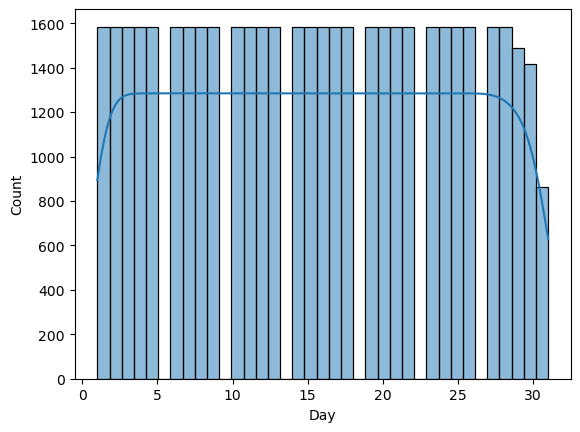

In [22]:
sns.histplot(x='Day',data=df,kde=True)

In [23]:
df['Day'].describe()

count    48120.000000
mean        15.700748
std          8.784073
min          1.000000
25%          8.000000
50%         16.000000
75%         23.000000
max         31.000000
Name: Day, dtype: float64

#### The data shows that records are available for all days of the month. The average day value is around **15.7**, meaning data is fairly spread across the month. Most records fall between **8 to 23 days**, showing a balanced distribution in the middle of the month. The minimum value is **1** and the maximum is **31**, which confirms that full monthly coverage is present in the dataset. Overall, the data is evenly distributed across all days.


### **Month**

<Axes: xlabel='Month', ylabel='count'>

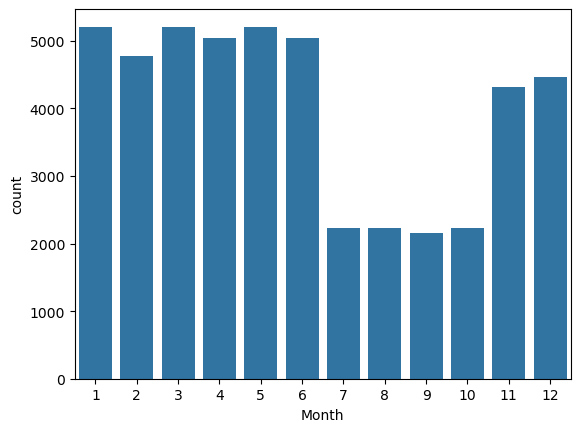

In [24]:
sns.countplot(x='Month',data=df)

In [25]:
df['Month'].value_counts()

Month
1     5208
3     5208
5     5208
4     5040
6     5040
2     4776
12    4464
11    4320
7     2232
8     2232
10    2232
9     2160
Name: count, dtype: int64

#### The dataset contains traffic records from all months, but the distribution is not equal. Months like **January, March, and May** have the highest records (**5208 each**), while months like **September, October, July, and August** have fewer records (around **2160–2232**). This uneven distribution shows that data collection varies across months. Overall, it helps in understanding monthly traffic patterns and seasonal variations.


### **Year**

<Axes: xlabel='Year', ylabel='count'>

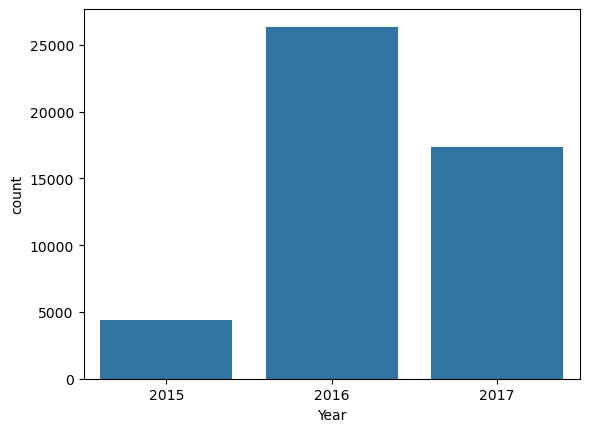

In [26]:
sns.countplot(x='Year',data=df)

In [27]:
df['Year'].value_counts()

Year
2016    26352
2017    17376
2015     4392
Name: count, dtype: int64

#### The dataset contains traffic records from three years: **2015, 2016, and 2017**. Most of the data is from **2016 (26,352 records)**, followed by **2017 (17,376 records)**, while **2015 has the least records (4,392)**. This shows that the dataset is heavily focused on 2016. Overall, it helps us understand how traffic data is distributed over different years, with 2016 being the most significant period for analysis.


### **Final Summary – Univariate Analysis**

#### The univariate analysis shows that each feature in the dataset has its own clear pattern. The traffic volume (Vehicles) varies significantly, with most values in a low to moderate range and occasional high spikes, showing changing traffic conditions. Junction-wise data is uneven, with some locations having more records than others. Time-based features like hour, day, month, and weekday show good coverage across all periods, helping to understand traffic behavior throughout the day, week, and year. Overall, the analysis shows that traffic data is dynamic and varies across time and locations.


### **Bivariate Analysis**

### **Identification of Target Variable**

#### The “Vehicles” column is considered the target feature because it represents the traffic volume, which is the main variable of interest in this dataset. All other features such as time, date, and junction are used to understand and explain variations in vehicle count.

### **Vehicles vs Hour**

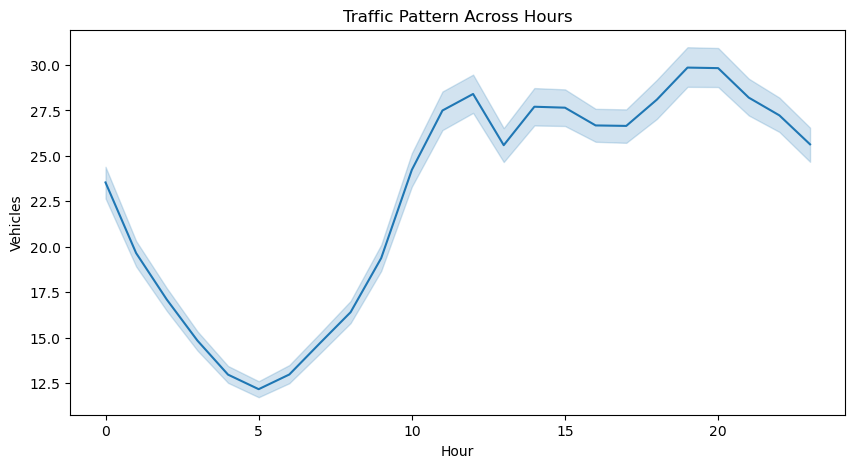

In [28]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Hour', y='Vehicles', data=df, estimator='mean')
plt.title("Traffic Pattern Across Hours")
plt.show()

In [29]:
df[['Hour','Vehicles']].corr()

,Hour,Vehicles
Hour,1.000000,0.219938
Vehicles,0.219938,1.000000


#### The correlation between Hour and Vehicles is 0.22, indicating a weak positive relationship between time of day and traffic volume. This suggests that traffic does not increase or decrease strongly in a linear manner across hours, but still shows some dependency on time.The traffic distribution shows high variability, with most values in the low to moderate range and occasional spikes reaching up to 180 vehicles. This indicates fluctuating traffic conditions throughout the day.



### **Vehicles vs Is_Weekend**

<Axes: xlabel='Is_Weekend', ylabel='Vehicles'>

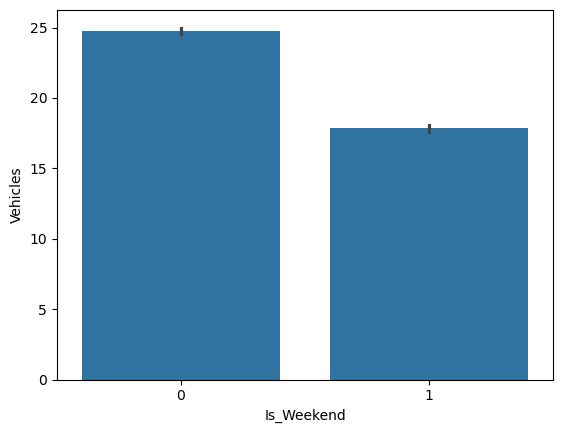

In [30]:
sns.barplot(x='Is_Weekend', y='Vehicles', data=df)

In [31]:
df.groupby('Weekday')['Vehicles'].agg(['mean', 'median', 'std', 'min', 'max'])

,mean,median,std,min,max
Weekday,,,,,
Friday,23.802120,16.0,20.688657,1,120
Monday,24.409408,16.0,22.838253,1,156
Saturday,18.544611,13.0,15.650178,1,134
Sunday,17.134727,12.0,14.231451,1,97
Thursday,25.152875,17.0,22.877303,1,180
Tuesday,25.286731,17.0,22.739926,1,140
Wednesday,25.149681,17.0,22.436645,1,124


#### Traffic clearly changes across the week. Mid-week days like Tuesday to Thursday have the highest traffic, while weekends show the lowest. The average is higher than the median on all days, which means a few high traffic spikes increase the overall values. Traffic is also very inconsistent, as shown by the high standard deviation. Overall, the data shows that traffic is heavier on weekdays and lighter on weekends, with occasional extreme congestion on all days.


### **Junction vs Vehicles**

<Axes: xlabel='Junction', ylabel='Vehicles'>

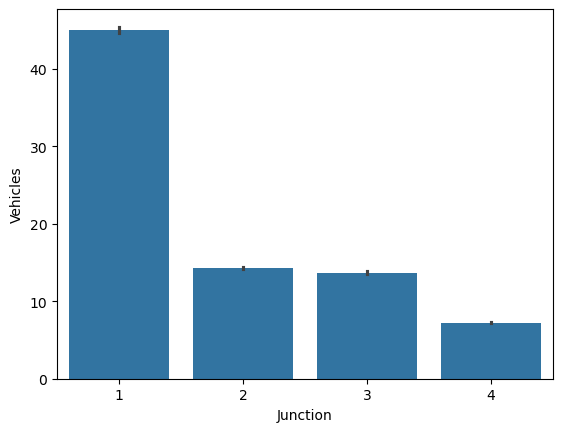

In [32]:
sns.barplot(x='Junction', y='Vehicles', data=df)

In [33]:
df.groupby('Junction')['Vehicles'].agg(['mean', 'median', 'std', 'min', 'max'])

,mean,median,std,min,max
Junction,,,,,
1,45.052906,40.0,23.008345,5,156
2,14.253221,13.0,7.401307,1,48
3,13.694010,11.0,10.436005,1,180
4,7.251611,7.0,3.521455,1,36


#### Traffic is not the same at all junctions. Junction 1 has the highest traffic, while Junction 4 has the lowest. This clearly shows that some locations are much busier than others. Overall, traffic is unevenly distributed across junctions, with noticeable differences in congestion levels.


### **Vehicles vs Weekday**

<Axes: xlabel='Weekday', ylabel='Vehicles'>

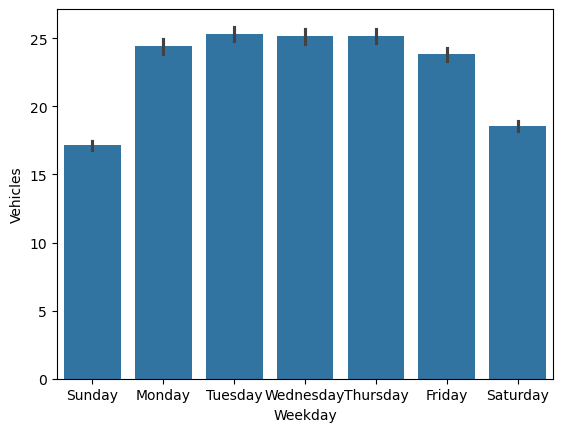

In [34]:
sns.barplot(x='Weekday', y='Vehicles', data=df)

In [35]:
df.groupby('Weekday')['Vehicles'].describe()

,count,mean,std,min,25%,50%,75%,max
Weekday,,,,,,,,
Friday,6888.0,23.802120,20.688657,1.0,9.0,16.0,32.0,120.0
Monday,6888.0,24.409408,22.838253,1.0,9.0,16.0,31.0,156.0
Saturday,6792.0,18.544611,15.650178,1.0,8.0,13.0,25.0,134.0
Sunday,6888.0,17.134727,14.231451,1.0,7.0,12.0,23.0,97.0
Thursday,6888.0,25.152875,22.877303,1.0,10.0,17.0,32.0,180.0
Tuesday,6888.0,25.286731,22.739926,1.0,10.0,17.0,33.0,140.0
Wednesday,6888.0,25.149681,22.436645,1.0,10.0,17.0,33.0,124.0


#### Traffic changes clearly across the week. Mid-week days like Tuesday, Wednesday, and Thursday have the highest traffic, while weekends show the lowest. Overall, weekdays are busier than weekends. The data also shows high variation and occasional traffic spikes, meaning congestion is not constant but happens at certain times.


### **Vehicles vs Month**

<Axes: xlabel='Month', ylabel='Vehicles'>

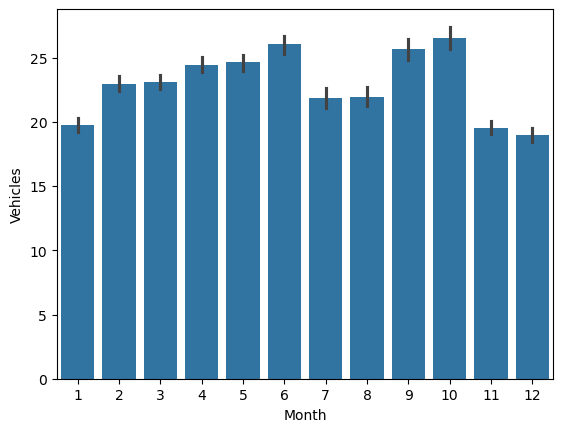

In [36]:
sns.barplot(x='Month', y='Vehicles', data=df)

In [37]:
df.groupby('Month')['Vehicles'].describe()

,count,mean,std,min,25%,50%,75%,max
Month,,,,,,,,
1,5208.0,19.727343,19.437632,1.0,7.0,12.0,23.0,133.0
2,4776.0,22.962312,20.729377,1.0,9.0,15.0,28.0,180.0
3,5208.0,23.073349,20.499683,1.0,9.0,16.0,29.0,110.0
4,5040.0,24.454365,20.587904,1.0,10.0,18.0,32.0,114.0
5,5208.0,24.633449,23.337280,1.0,9.0,16.0,32.0,136.0
6,5040.0,26.032143,25.252269,1.0,9.0,16.0,34.0,162.0
7,2232.0,21.837814,17.403989,2.0,9.0,15.0,30.0,134.0
8,2232.0,21.936380,17.678499,1.0,9.0,15.0,30.0,97.0
9,2160.0,25.644907,19.399277,2.0,11.0,18.0,35.0,93.0


#### Traffic shows clear variation across months. Mid-year months like **June, September, and October** have the highest average traffic, while **December and January** show lower traffic levels. Overall, traffic gradually increases from early months, peaks in mid-year, and then decreases towards the end of the year. The data also shows high variability and occasional spikes in all months, indicating inconsistent traffic conditions.


### **Vehicles vs Year**

<Axes: xlabel='Year', ylabel='Vehicles'>

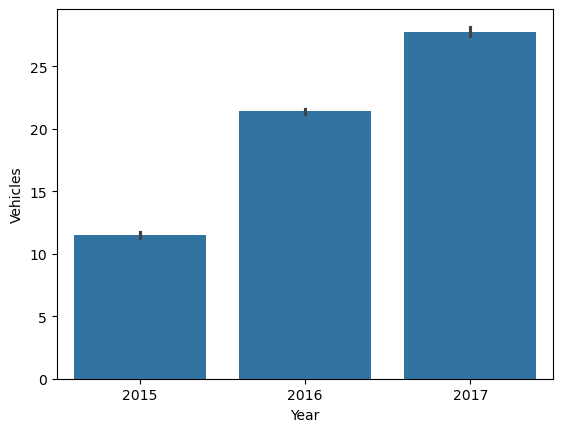

In [38]:
sns.barplot(x='Year', y='Vehicles', data=df)

In [39]:
df.groupby('Year')['Vehicles'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2015,4392.0,11.510018,8.558765,1.0,5.0,9.0,15.0,50.0
2016,26352.0,21.386916,17.103341,1.0,9.0,15.0,29.0,134.0
2017,17376.0,27.772733,25.889963,1.0,9.0,18.0,37.0,180.0


#### Traffic shows a clear increasing trend over the years. In 2015, traffic levels were relatively low, while 2016 shows a noticeable increase. By 2017, traffic reaches its highest levels with both higher average values and larger spikes. This indicates growing traffic demand over time. The high variability in 2017 also suggests more frequent congestion and extreme traffic conditions compared to earlier years.


### **Vehicles vs Day**

<Axes: xlabel='Day', ylabel='Vehicles'>

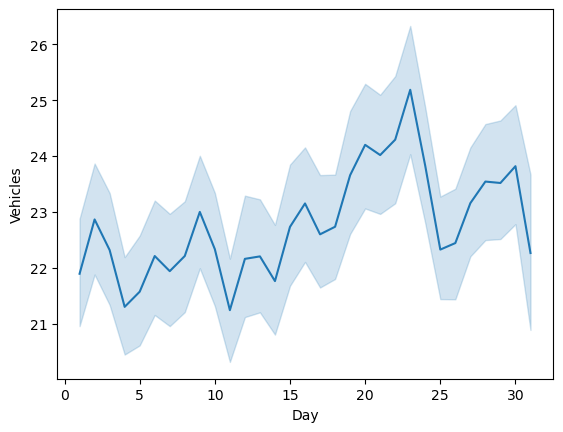

In [40]:
sns.lineplot(x='Day', y='Vehicles', data=df)

In [41]:
df.groupby('Day')['Vehicles'].describe()

,count,mean,std,min,25%,50%,75%,max
Day,,,,,,,,
1,1584.0,21.891414,19.868095,1.0,9.00,15.0,27.25,121.0
2,1584.0,22.864268,20.422570,1.0,9.00,16.0,29.00,120.0
3,1584.0,22.316288,19.977159,1.0,9.00,15.0,28.00,105.0
4,1584.0,21.298611,18.904651,1.0,8.00,14.0,29.00,103.0
5,1584.0,21.570076,19.697719,1.0,8.00,14.0,28.00,106.0
6,1584.0,22.208965,21.258566,1.0,9.00,15.0,27.00,140.0
7,1584.0,21.938131,20.552998,1.0,8.00,15.0,27.00,133.0
8,1584.0,22.209596,20.646843,1.0,9.00,15.0,28.00,114.0
9,1584.0,22.999369,21.334786,1.0,9.00,15.0,29.00,105.0


#### Traffic shows a fairly stable pattern across the days of the month. The average traffic mostly stays around 21–25 vehicles, with small fluctuations between days. However, later days like 20 to 23 show slightly higher averages, indicating increased traffic activity. The median is consistently lower than the mean, which shows occasional high spikes in traffic. Overall, traffic does not change drastically day-to-day but shows small variations with some peak congestion on certain days.


### **Final Summary — Bivariate Analysis**

#### The bivariate analysis shows clear relationships between traffic volume and different factors like time, day, month, junction, and weekend effect. Overall, traffic is not constant and changes based on these variables.
#### Traffic is higher on weekdays compared to weekends, and mid-week days show the most congestion. Junction-wise analysis shows that some locations (especially Junction 1) experience much heavier traffic than others, proving that location strongly affects vehicle flow. Over time, traffic also increases across years and shows seasonal variation across months, with mid-year periods having slightly higher activity.
#### Hour-wise analysis indicates that traffic changes throughout the day, with patterns suggesting peak and low traffic periods. However, the relationship between hour and traffic is weak but still shows variation, indicating time-based fluctuations rather than a strict linear trend.
#### Overall, bivariate analysis confirms that traffic is influenced by multiple factors such as time, day, month, and location, with clear variations and occasional congestion spikes across all dimensions.


### **Hypothesis Evaluation**

### **H1 (Time-based Traffic Pattern)**
#### Hypothesis: Vehicle counts show higher traffic during morning and evening peak hours due to commuting activity.


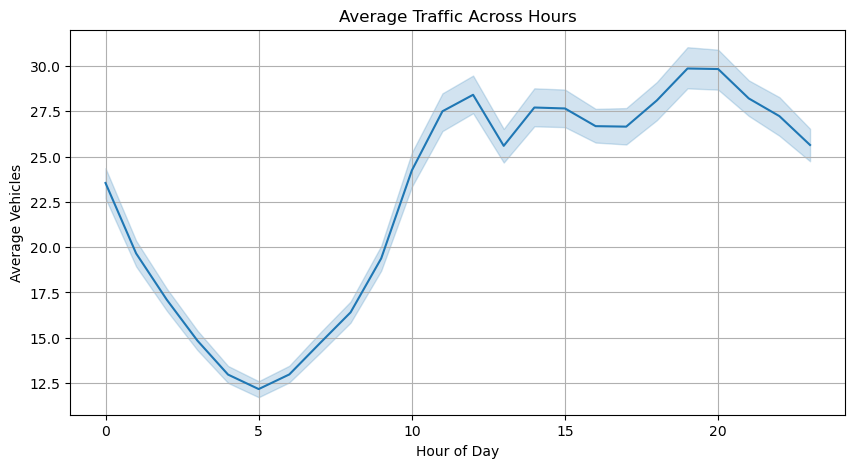

In [42]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Hour', y='Vehicles', data=df, estimator='mean')
plt.title("Average Traffic Across Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicles")
plt.grid(True)
plt.show()

#### The hourly traffic pattern shows a non-uniform distribution with two distinct peaks observed during the day. Traffic increases significantly during morning hours, likely due to work and school commuting, followed by a decrease during mid-day. A second peak appears in the evening, corresponding to return travel. This pattern confirms the **Hypothesis 1**the presence of a bimodal distribution in traffic behavior, reflecting typical daily human movement cycles.

### **H1 (Time-based Traffic Pattern)**
#### Hypothesis: Vehicle counts show higher traffic during morning and evening peak hours due to commuting activity.


<Axes: xlabel='Is_Weekend', ylabel='Vehicles'>

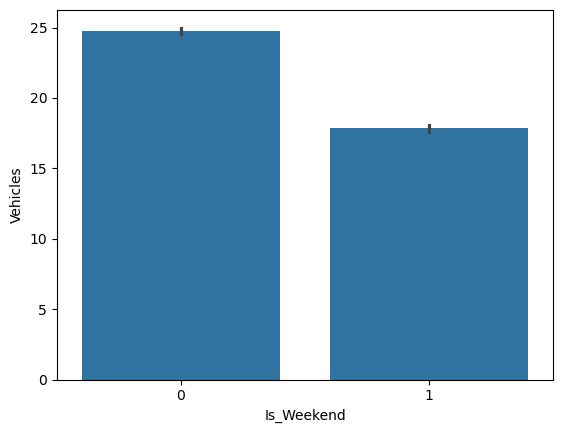

In [43]:
sns.barplot(x='Is_Weekend', y='Vehicles', data=df)
plt.savefig(r"images/traffic_pattern.png")

#### Weekdays (0) show higher average traffic. Weekends (1) show comparatively lower and smoother traffic. 
#### **The hypothesis** is confirmed. Traffic is heavier on weekdays due to work-related travel, while weekends show reduced and more balanced traffic flow.

### **H3 (Junction-wise Traffic Difference)**
#### Hypothesis: Different junctions experience different traffic volumes, with some acting as bottlenecks.


<Axes: xlabel='Junction', ylabel='Vehicles'>

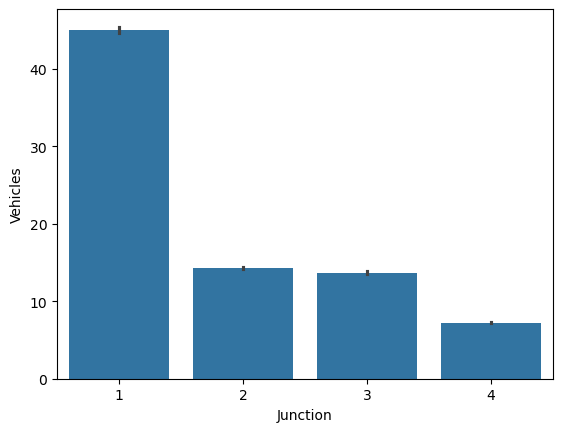

In [44]:
sns.barplot(x='Junction', y='Vehicles', data=df)

#### Junctions 1, 2, and 3 show higher traffic levels. Junction 4 has comparatively lower traffic. Traffic distribution is uneven across locations. 
#### **The hypothesis** is confirmed. Traffic is not evenly distributed, and some junctions consistently handle more vehicles, acting as major congestion points.

#### **FINAL OVERALL CONCLUSION OF HYPOTHESIS**
#### The hypothesis testing clearly shows that traffic behavior is strongly influenced by time and location. Traffic follows a clear daily pattern with peak hours in the morning and evening. Weekdays experience higher traffic compared to weekends due to regular work routines. Additionally, traffic distribution across junctions is uneven, indicating that certain intersections act as major congestion points. Overall, the dataset confirms that traffic is dynamic and depends on both temporal and spatial factors.


### **MULTIVARIATE ANALYSIS**

### Heatmap (Correlation Analysis)

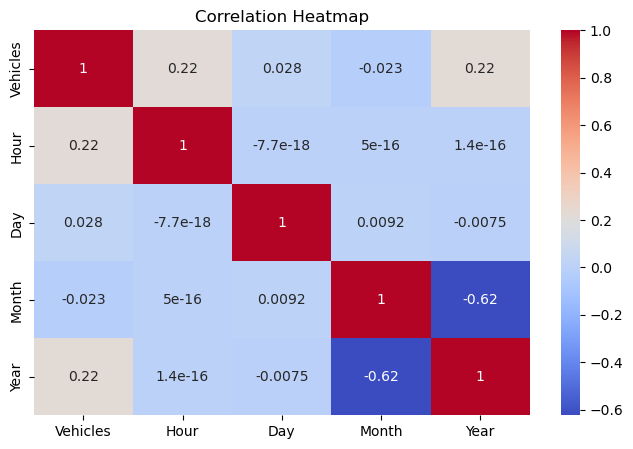

In [45]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Vehicles','Hour','Day','Month','Year']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [46]:
df[['Vehicles','Hour','Day','Month','Year']].corr()

,Vehicles,Hour,Day,Month,Year
Vehicles,1.000000,2.199377e-01,2.789498e-02,-2.272345e-02,2.212531e-01
Hour,0.219938,1.000000e+00,-7.654487e-18,4.967201e-16,1.431536e-16
Day,0.027895,-7.654487e-18,1.000000e+00,9.154760e-03,-7.474779e-03
Month,-0.022723,4.967201e-16,9.154760e-03,1.000000e+00,-6.234957e-01
Year,0.221253,1.431536e-16,-7.474779e-03,-6.234957e-01,1.000000e+00


#### The correlation heatmap was used to examine the statistical relationship between numerical variables such as Vehicles, Hour, Day, Month, and Year.
#### The analysis shows that Vehicles has a moderate positive correlation with both Hour (0.22) and Year (0.22). This means traffic volume tends to vary according to the time of day and also changes gradually over the years.On the other hand, Day (0.03) and Month (-0.02) show very weak correlations with vehicle count, indicating that these features have little direct impact on traffic volume.Additionally, Month and Year (-0.62) have a strong negative correlation, which suggests an inverse relationship between these two variables in the dataset structure.

#### The correlation analysis confirms that traffic volume is more dependent on time-based patterns, particularly hourly trends and yearly changes, while day and month individually have minimal influence on vehicle count. Overall, temporal features play a key role in understanding traffic behavior.

### **Hour + Weekend + Vehicles**

<Axes: xlabel='Hour', ylabel='Vehicles'>

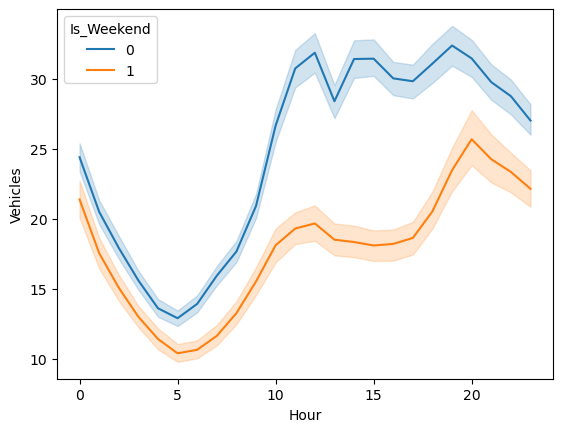

In [47]:
sns.lineplot(x='Hour',y='Vehicles',hue='Is_Weekend',data=df)


In [48]:
df.groupby(['Hour','Is_Weekend'])['Vehicles'].agg(['mean','median','std'])

mean  median        std
Hour Is_Weekend                              
0    0           24.399303    16.0  19.969960
     1           21.378947    15.0  16.724909
1    0           20.495470    14.0  17.130656
     1           17.538596    12.0  13.826165
2    0           17.912195    12.0  14.980716
     1           15.064912    11.0  11.604995
3    0           15.585366    10.0  12.987718
     1           12.989474     9.0  10.285378
4    0           13.597909     9.0  11.266240
     1           11.400000     8.0   8.803339
5    0           12.887108     9.0  10.591756
     1           10.377193     7.0   7.982836
6    0           13.913589     9.0  11.841211
     1           10.629825     7.0   8.243535
7    0           15.926829    10.0  13.454280
     1           11.622807     8.0   8.906062
8    0           17.655749    11.0  14.796479
     1           13.249123    10.0  10.092248
9    0           20.914286    13.0  17.383693
     1           15.515789    11.0  11.914632
10   0           26.663415    16.0  22.550925
     1           18.103509    13.0  13.995159
11   0           30.750523    19.0  26.279061
     1           19.300000    14.0  14.776822
12   0           31.875261    20.0  26.732998
     1           19.664912    14.0  14.763692
13   0           28.402787    18.0  23.536363
     1           18.503509    13.0  13.775025
14   0           31.423693    20.0  26.026062
     1           18.335088    13.0  13.503563
15   0           31.448780    21.0  25.365075
     1           18.087719    13.0  13.393833
16   0           30.039721    20.0  24.062922
     1           18.201754    13.5  13.292161
17   0           29.834843    20.0  23.873064
     1           18.626316    14.0  13.861695
18   0           31.098955    20.0  26.078093
     1           20.533333    14.0  16.180325
19   0           32.389547    20.0  27.417217
     1           23.473684    15.0  18.560503
20   0           31.467596    20.0  26.338443
     1           25.689474    16.0  22.546809
21   0           29.770732    20.0  24.617599
     1           24.256140    15.0  20.531882
22   0           28.766551    19.0  23.492347
     1           23.350877    16.0  17.903757
23   0           27.023693    18.0  21.976518
     1           22.140351    15.5  16.644889

#### The combined analysis of Hour, Weekend, and Vehicles shows clear differences between weekday and weekend traffic patterns. Weekdays display stronger morning and evening traffic peaks, reflecting regular office and commuting behavior. In comparison, weekends show relatively smoother and lower traffic flow across most hours.
#### **Mathematical Pattern**
#### Average vehicle count remains higher during weekday peak hours compared to weekends.
#### **Insight**
#### Traffic demand is strongly affected by both time of day and day type.

### **Hour + Junction + Vehicles**

Text(0.5, 1.0, 'Traffic Pattern: Hour vs Junction')

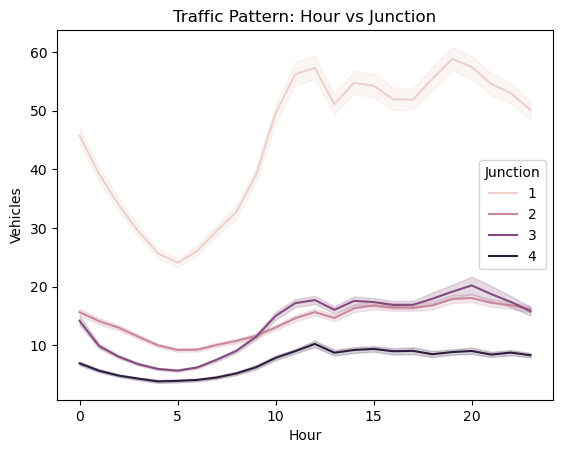

In [49]:
sns.lineplot(x='Hour',y='Vehicles',hue='Junction',data=df)
plt.title("Traffic Pattern: Hour vs Junction")

In [50]:
df.groupby(['Hour','Junction'])['Vehicles'].agg(['mean','median','std'])

mean  median        std
Hour Junction                              
0    1         45.738487    44.0  18.201029
     2         15.656250    14.0   7.131289
     3         14.174342    12.0  10.035154
     4          6.922652     7.0   2.324886
1    1         39.156250    37.0  15.558687
...                  ...     ...        ...
22   4          8.762431     8.0   3.136509
23   1         50.088816    49.0  19.964681
     2         16.174342    15.0   7.320113
     3         15.800987    14.0   9.347838
     4          8.309392     8.0   2.698430

[96 rows x 3 columns]

#### The relationship between Hour, Junction, and Vehicles highlights that traffic patterns vary across different locations throughout the day. Some junctions consistently experience higher average traffic and congestion during peak hours, while others remain comparatively less crowded.
#### **Mathematical Pattern**
#### Grouped mean analysis shows noticeable variation in vehicle count between junctions across different hours.
#### **Insight**
#### Location plays a major role in determining traffic intensity and congestion timing.

### **Month + Year + Vehicles**

Text(0.5, 1.0, 'Monthly Traffic Trend by Year')

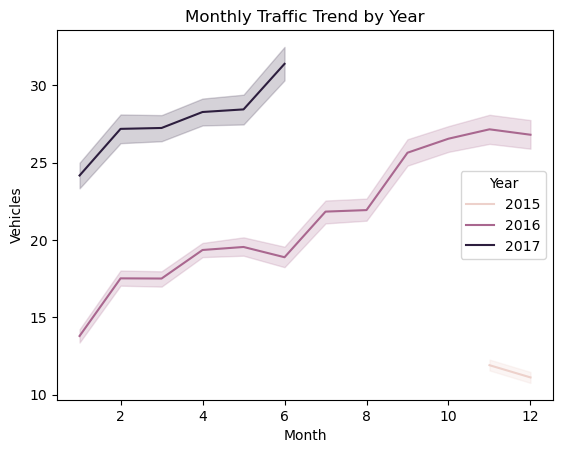

In [51]:
sns.lineplot(x='Month',y='Vehicles',hue='Year',data=df)
plt.title("Monthly Traffic Trend by Year")

In [52]:
df.groupby(['Year','Month'])['Vehicles'].agg(['mean','median','std'])

mean  median        std
Year Month                              
2015 11     11.911574     9.0   8.305316
     12     11.121416     8.0   8.781477
2016 1      13.799731    10.0  10.067533
     2      17.524425    13.5  11.627314
     3      17.512993    13.0  11.906020
     4      19.358333    15.0  12.067754
     5      19.552419    15.0  13.711732
     6      18.889815    13.0  15.341350
     7      21.837814    15.0  17.403989
     8      21.936380    15.0  17.678499
     9      25.644907    18.0  19.399277
     10     26.551075    18.0  20.241352
     11     27.156944    17.0  21.477756
     12     26.806452    17.0  22.062687
2017 1      24.173051    15.0  23.219449
     2      27.186384    17.0  24.855336
     3      27.243616    19.0  24.261588
     4      28.276389    21.0  24.465513
     5      28.444220    18.0  27.898898
     6      31.388889    20.0  29.540245

#### The month and year analysis reveals seasonal and yearly changes in traffic volume. Traffic gradually increases in later years, especially in 2017, where both average traffic and variability are highest. Certain months also show slightly increased traffic activity, indicating seasonal movement patterns.
#### **Mathematical Pattern**
#### Mean traffic values increase year by year, with higher standard deviation in recent years.
#### **Insight**
#### Traffic demand has grown over time, with visible seasonal fluctuations.

### **Weekday + Hour + Vehicles**

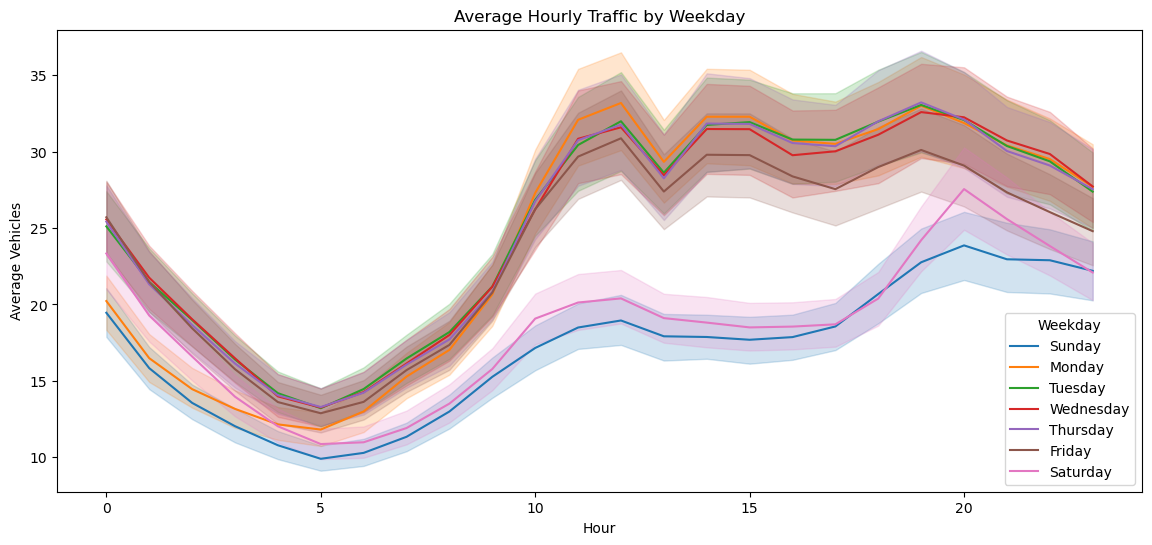

In [53]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df,x='Hour',y='Vehicles',hue='Weekday',estimator='mean')
plt.title('Average Hourly Traffic by Weekday')
plt.xlabel('Hour')
plt.ylabel('Average Vehicles')
plt.show()

In [54]:
df.groupby(['Weekday','Hour'])['Vehicles'].agg(['mean','median','std'])

mean  median        std
Weekday   Hour                              
Friday    0     25.700348    17.0  20.797074
          1     21.466899    15.0  17.637912
          2     18.439024    12.0  15.468068
          3     15.759582    11.0  13.241756
          4     13.609756     9.0  11.516223
...                   ...     ...        ...
Wednesday 19    32.581882    21.0  27.313629
          20    32.240418    20.0  26.666839
          21    30.724739    20.0  24.989876
          22    29.839721    19.0  24.200404
          23    27.714286    18.0  22.549136

[168 rows x 3 columns]

#### This analysis combines weekdays, hours, and traffic volume to understand how daily schedules influence congestion. Mid-week weekdays and peak commuting hours show the highest traffic levels, while weekends remain comparatively lighter.
#### **Mathematical Pattern**
#### Average traffic is highest during weekday peak hours and lower during off-peak periods.
#### **Insight**
#### Traffic patterns strongly follow human commuting and work-related schedules.

### **Junction + Weekend + Vehicles**

Text(0.5, 1.0, 'Junction Traffic: Weekday vs Weekend')

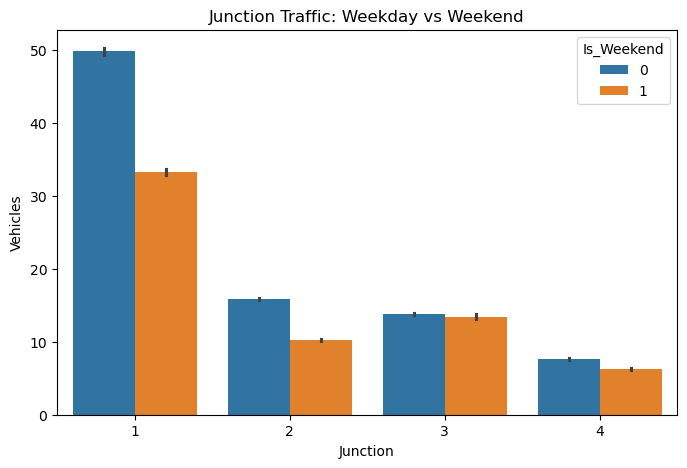

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(x='Junction',y='Vehicles',hue='Is_Weekend',data=df)
plt.title("Junction Traffic: Weekday vs Weekend")

In [56]:
df.groupby(['Junction','Is_Weekend'])['Vehicles'].agg(['mean','median','std'])

mean  median        std
Junction Is_Weekend                              
1        0           49.766858    45.0  24.053447
         1           33.199904    31.0  14.470882
2        0           15.834291    14.0   7.734143
         1           10.277697     9.0   4.475281
3        0           13.793199    12.0   9.531554
         1           13.444605    10.0  12.420397
4        0            7.648397     7.0   3.661770
         1            6.240196     6.0   2.900839

### The analysis of junctions with weekend effect shows that some junctions remain highly active even during weekends. While overall traffic decreases on weekends, major junctions still experience moderate to high congestion.
#### **Mathematical Pattern**
#### Mean vehicle count differs significantly across junctions for both weekdays and weekends.
#### **Insight**
#### Certain locations maintain consistent traffic activity regardless of day type

### **Final Multivariate Summary**
#### The multivariate analysis shows that traffic behavior is influenced by the combined effect of time, location, weekdays, weekends, and seasonal trends. Mathematical statistics such as grouped mean, correlation, and variability analysis reveal that traffic is not controlled by a single factor. Peak hours, busy junctions, working days, and yearly growth patterns together contribute to changing traffic conditions. Overall, the dataset reflects highly dynamic traffic behavior with clear congestion patterns across different combinations of variables.

### **Business Impact**

#### This analysis provides useful insights for improving traffic management and city planning. The results show that traffic is not constant and changes based on time, location, day type, and season.

#### Based on these findings, several practical actions can be taken:

#### Traffic control optimization to reduce congestion
#### Signal timing adjustment during peak hours
#### Better management of peak traffic periods (morning and evening rush)
#### Junction-wise planning for high-traffic locations

#### Overall, these insights can help improve traffic flow, reduce congestion, and make daily commuting more efficient for the public

### **Final Conclusion**

#### The exploratory data analysis of the traffic dataset reveals clear and meaningful patterns in traffic behavior. Traffic is highly dynamic and changes based on multiple factors such as time, location, day type, month, and year.

#### The analysis shows that weekdays generally experience higher traffic compared to weekends, with mid-week days showing the most congestion. Junction-wise analysis confirms that traffic is unevenly distributed, with some locations like Junction 1 experiencing significantly higher traffic than others. Hour-wise patterns indicate fluctuating traffic throughout the day, suggesting peak and off-peak periods influenced by daily commuting behavior.

#### Seasonal and yearly trends show that traffic varies over time, with noticeable growth in recent years and fluctuations across different months. Overall, the data is highly variable and positively skewed, indicating occasional extreme congestion events.
#### In conclusion, traffic behavior is not driven by a single factor but is the result of a combined effect of time, location, and day-based patterns. These insights can help in better traffic planning, congestion management, and improving overall transportation efficiency.
